## 1. Load Dataset and Import libraries

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error


X_train = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\train_features.csv')
y_train = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\train_target.csv')
X_val = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\val_features.csv')
y_val = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\val_target.csv')
y_val_orig = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\val_target_original.csv')
X_test = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\splits\test_features.csv')
y_test = pd.read_csv(r'D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\test_target_encoding.csv')








## 1b. Encode categorical features

In [16]:
object_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
label_encoders = {}

for col in object_cols:
    le = LabelEncoder()
    parts = [X_train[col], X_val[col]]
    if col in X_test.columns:
        parts.append(X_test[col])
    combined = pd.concat(parts, ignore_index=True).astype(str)
    le.fit(combined)

    X_train[col] = le.transform(X_train[col].astype(str)).astype(np.int32)
    X_val[col] = le.transform(X_val[col].astype(str)).astype(np.int32)
    if col in X_test.columns:
        X_test[col] = le.transform(X_test[col].astype(str)).astype(np.int32)

    label_encoders[col] = le
    print(f"  {col}: {len(le.classes_)} nhãn → 0..{len(le.classes_) - 1}")

rest = X_train.select_dtypes(include=["object"]).columns.tolist()
if rest:
    raise ValueError(f"Vẫn còn cột object: {rest}")

print(f"\nĐã LabelEncoder {len(object_cols)} cột | X_train {X_train.shape} | X_val {X_val.shape} | X_test {X_test.shape}")

  date: 1700 nhãn → 0..1699
  family: 33 nhãn → 0..32
  type: 6 nhãn → 0..5
  city: 23 nhãn → 0..22
  state: 17 nhãn → 0..16

Đã LabelEncoder 5 cột | X_train (2974158, 48) | X_val (26730, 48) | X_test (28512, 48)


## 2. LightGBM Training

In [17]:
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=150,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    objective="regression", 
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=100)],
)




[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.117764 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5225
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 47
[LightGBM] [Info] Start training from score 2.920052
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l2: 0.150546
[200]	valid_0's l2: 0.14654
[300]	valid_0's l2: 0.144531
[400]	valid_0's l2: 0.143139
[500]	valid_0's l2: 0.142265
[600]	valid_0's l2: 0.141643
[700]	valid_0's l2: 0.141148
[800]	valid_0's l2: 0.140828
[900]	valid_0's l2: 0.14051
[1000]	valid_0's l2: 0.140208
Did not meet early stopping. Best iteration is:
[999]	valid_0's l2: 0.140208


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, min_child_samples=100,
              n_estimators=1000, n_jobs=-1, num_leaves=150,
              objective='regression', random_state=42, reg_alpha=0.1,
              reg_lambda=0.1, subsample=0.8)

## 3. Feature Importance

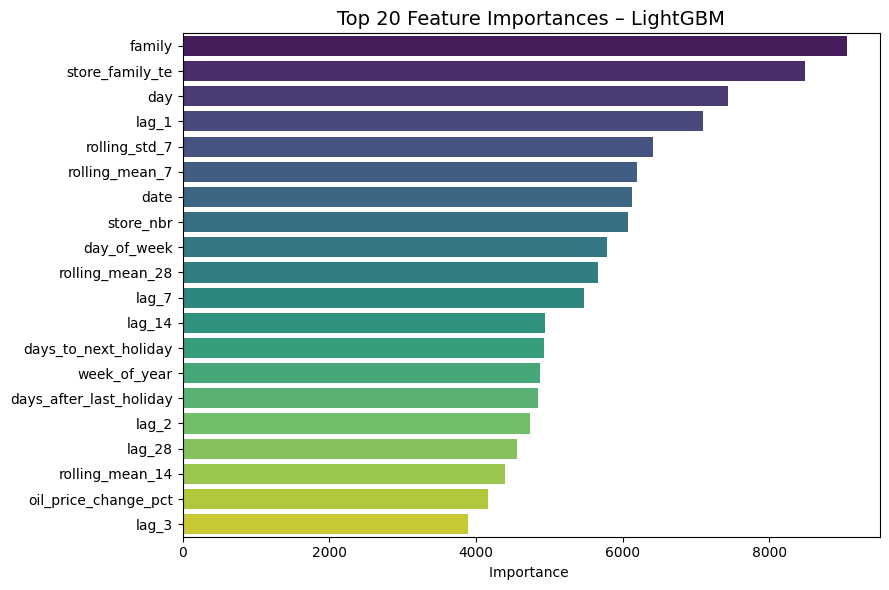


Top 20 features:
                feature  importance
                 family        9057
        store_family_te        8488
                    day        7442
                  lag_1        7090
          rolling_std_7        6415
         rolling_mean_7        6193
                   date        6129
              store_nbr        6069
            day_of_week        5790
        rolling_mean_28        5670
                  lag_7        5469
                 lag_14        4945
   days_to_next_holiday        4933
           week_of_year        4876
days_after_last_holiday        4851
                  lag_2        4736
                 lag_28        4554
        rolling_mean_14        4392
   oil_price_change_pct        4163
                  lag_3        3888


In [18]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

top_n = 20
top_df = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(
    data=top_df, x='importance', y='feature',
    hue='feature', palette='viridis', legend=False, ax=ax
)
ax.set_title(f'Top {top_n} Feature Importances – LightGBM', fontsize=14)
ax.set_xlabel('Importance ')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print(f"\nTop {top_n} features:")
print(top_df.to_string(index=False))

## 4.Evaluation Metrics

In [21]:
def regression_metrics(y_true, y_pred):
    """y_true, y_pred: sales_log (log1p doanh số)."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    sales_true = np.expm1(y_true)
    sales_pred = np.maximum(np.expm1(y_pred), 0.0)

    rmse_log = np.sqrt(mean_squared_error(y_true, y_pred))
    rmsle = np.sqrt(mean_squared_log_error(sales_true, sales_pred))
    mae = mean_absolute_error(sales_true, sales_pred)
    rmse = np.sqrt(mean_squared_error(sales_true, sales_pred))
    eps = 1e-8
    mape = np.mean(np.abs((sales_true - sales_pred) / np.maximum(sales_true, eps))) * 100

    return {
        "RMSLE": float(round(rmsle, 4)),
        "RMSE": float(round(rmse, 4)),
        "MAE": float(round(mae, 4)),
        "MAPE": float(round(mape, 4)),
        "RMSE_Log": float(round(rmse_log, 4)),
    }


y_val_arr = y_val["sales_log"].values
y_pred_val = model.predict(X_val)
metrics_val = regression_metrics(y_val_arr, y_pred_val)

metrics_df = pd.DataFrame([metrics_val]).T
metrics_df.columns = ["validation"]
print("LightGBM —  Validation:\n")
print(metrics_df.round(6).to_string())


LightGBM —  Validation:

            validation
RMSLE     3.744000e-01
RMSE      2.082357e+02
MAE       6.161760e+01
MAPE      5.359034e+08
RMSE_Log  3.744000e-01


## 5. Error Analysis

In [22]:
# ── Setup val_df — dataframe trung tâm cho toàn bộ error analysis ──
y_pred_val      = model.predict(X_val)
val_pred_actual = np.maximum(np.expm1(y_pred_val), 0.0)
y_actual        = y_val_orig["sales"].values if isinstance(y_val_orig, pd.DataFrame) else y_val_orig.values

# Reconstruct date từ year/month/day columns
date_val = pd.to_datetime(X_val[["year", "month", "day"]])

val_df = pd.DataFrame({
    "date"      : date_val.values,
    "store_nbr" : X_val["store_nbr"].values,
    "family"    : X_val["family"].values,
    "actual"    : y_actual,
    "predicted" : val_pred_actual,
})
val_df["residual"] = val_df["actual"] - val_df["predicted"]

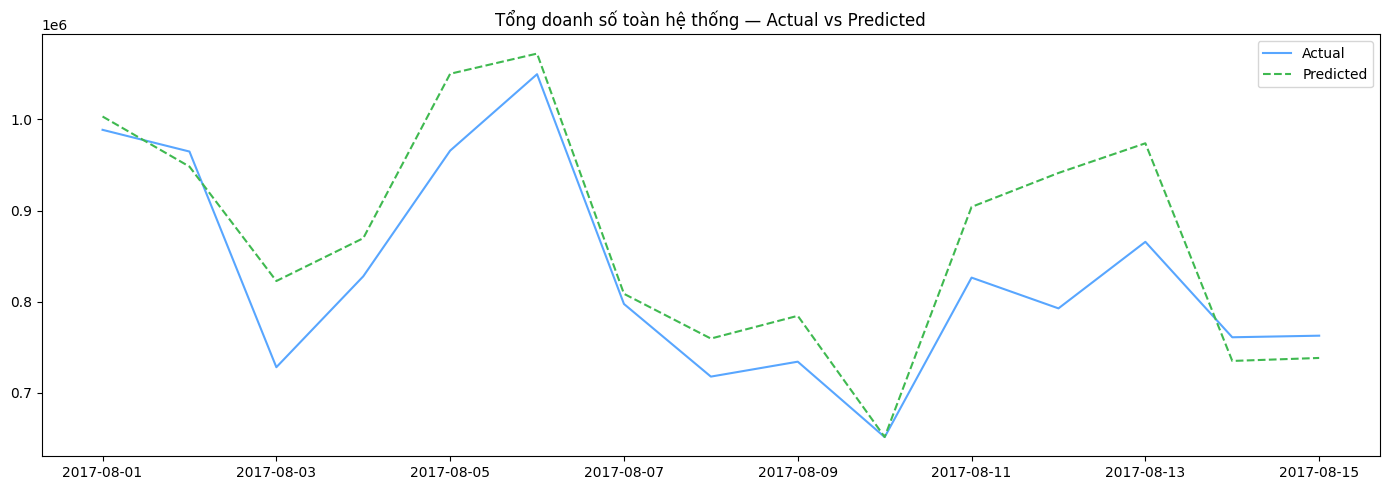

In [23]:
y_pred_val = model.predict(X_val)
val_pred_actual = np.maximum(np.expm1(y_pred_val), 0.0)

date_val = pd.to_datetime(X_val[["year", "month", "day"]])

daily = pd.DataFrame({
    "date": date_val,
    "actual": y_val_orig["sales"].values,
    "predicted": val_pred_actual,
}).groupby("date").sum()

plt.figure(figsize=(14, 5))
plt.plot(daily.index, daily["actual"], label="Actual", color="#58a6ff")
plt.plot(daily.index, daily["predicted"], label="Predicted", color="#3fb950", linestyle="--")
plt.title("Tổng doanh số toàn hệ thống — Actual vs Predicted")
plt.legend()
plt.tight_layout()

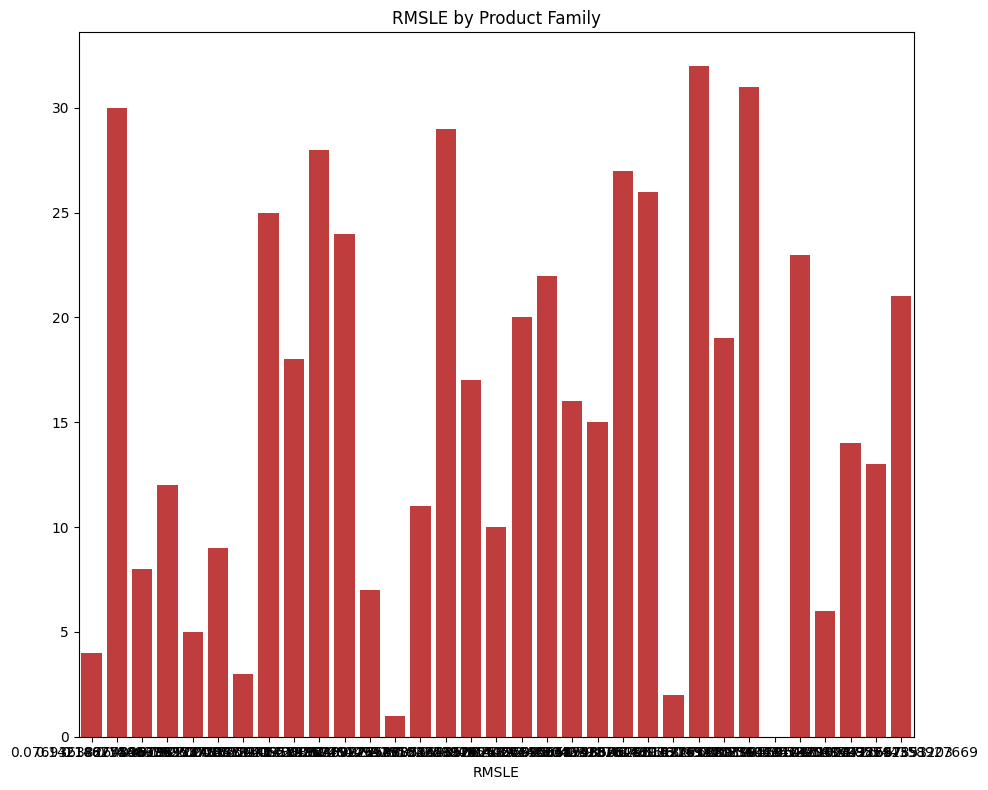

Top 5 families có RMSLE cao nhất:
 family    rmsle
     21 0.598554
     13 0.548410
     14 0.529182
      6 0.525732
     23 0.510475


In [25]:
# ── Plot 2: RMSLE theo product family ──
family_results = []
for family in val_df["family"].unique():
    mask = val_df["family"] == family
    sub  = val_df[mask]
    r = np.sqrt(mean_squared_log_error(
        sub["actual"].clip(0), sub["predicted"].clip(0)
    ))
    family_results.append({"family": family, "rmsle": r})

df_family = pd.DataFrame(family_results).sort_values("rmsle", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=df_family, x="rmsle", y="family", color="#d62728", ax=ax)
ax.set_title("RMSLE by Product Family")
ax.set_xlabel("RMSLE"); ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("Top 5 families có RMSLE cao nhất:")
print(df_family.head(5).to_string(index=False))

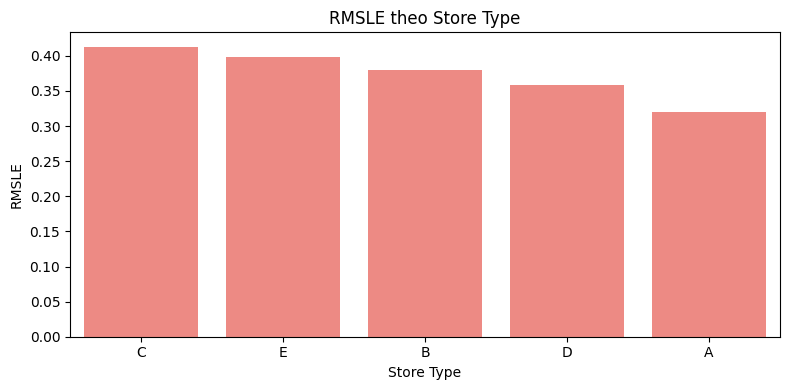

In [26]:
# ── Plot 3: RMSLE theo store type ──
stores = pd.read_csv(r"D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\stores_cleaned.csv")
val_store = val_df.merge(stores[["store_nbr", "type"]], on="store_nbr", how="left")

store_results = []
for stype in val_store["type"].unique():
    mask = val_store["type"] == stype
    sub  = val_store[mask]
    r = np.sqrt(mean_squared_log_error(
        sub["actual"].clip(0), sub["predicted"].clip(0)
    ))
    store_results.append({"store_type": stype, "rmsle": r})

df_store = pd.DataFrame(store_results).sort_values("rmsle", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df_store, x="store_type", y="rmsle", color="#ff7b72", ax=ax)
ax.set_title("RMSLE theo Store Type")
ax.set_xlabel("Store Type"); ax.set_ylabel("RMSLE")
plt.tight_layout()
plt.show()

Holiday: RMSLE = 0.3708 (7,128 rows)
Non-Holiday: RMSLE = 0.3757 (19,602 rows)


C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_4104\3017523350.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_hol, x="label", y="rmsle", palette=["#ffa657", "#58a6ff"], ax=ax)


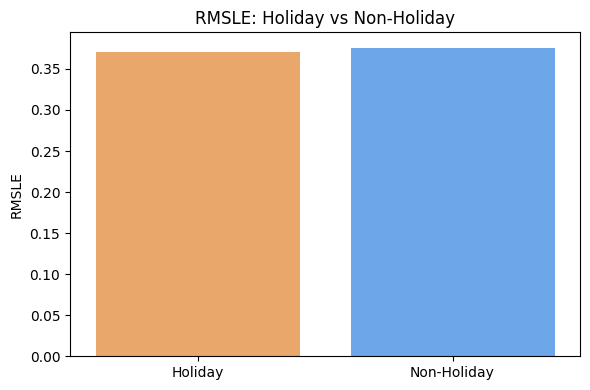

In [27]:
# ── Plot 4: Ngày lễ vs Ngày thường ──
holidays = pd.read_csv(r"D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series\data\processed\holidays_events_cleaned.csv")
holiday_dates         = set(pd.to_datetime(holidays["date"]).dt.strftime("%Y-%m-%d"))
val_df["date_str"]    = pd.to_datetime(val_df["date"]).dt.strftime("%Y-%m-%d")
val_df["is_holiday"]  = val_df["date_str"].isin(holiday_dates)

holiday_summary = []
for label, mask in [("Holiday", val_df["is_holiday"]), ("Non-Holiday", ~val_df["is_holiday"])]:
    sub = val_df[mask]
    r   = np.sqrt(mean_squared_log_error(sub["actual"].clip(0), sub["predicted"].clip(0)))
    holiday_summary.append({"label": label, "rmsle": r, "n_rows": mask.sum()})
    print(f"{label}: RMSLE = {r:.4f} ({mask.sum():,} rows)")

fig, ax = plt.subplots(figsize=(6, 4))
df_hol = pd.DataFrame(holiday_summary)
sns.barplot(data=df_hol, x="label", y="rmsle", palette=["#ffa657", "#58a6ff"], ax=ax)
ax.set_title("RMSLE: Holiday vs Non-Holiday")
ax.set_xlabel(""); ax.set_ylabel("RMSLE")
plt.tight_layout()
plt.show()

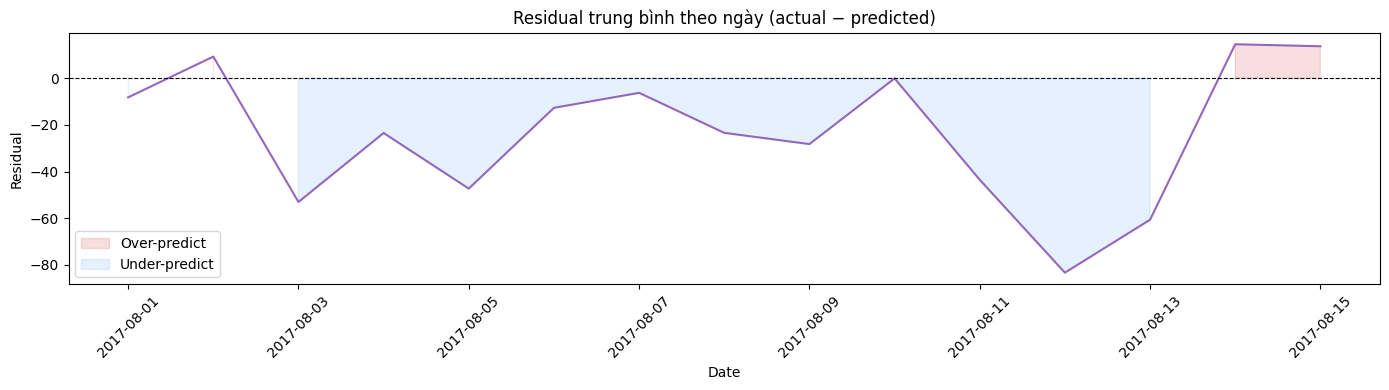

In [28]:
# ── Plot 5: Residual theo ngày ──
daily_resid = val_df.groupby("date")["residual"].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_resid.index, daily_resid.values, color="#9467bd", linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.fill_between(daily_resid.index, daily_resid.values, 0,
                where=daily_resid.values > 0, alpha=0.15, color="#d62728", label="Over-predict")
ax.fill_between(daily_resid.index, daily_resid.values, 0,
                where=daily_resid.values < 0, alpha=0.15, color="#58a6ff", label="Under-predict")
ax.set_title("Residual trung bình theo ngày (actual − predicted)")
ax.set_xlabel("Date"); ax.set_ylabel("Residual")
ax.legend(); plt.xticks(rotation=45); plt.tight_layout()
plt.show()

In [29]:
# ── Summary ──
print("\n" + "="*45)
print("ERROR ANALYSIS SUMMARY")
print("="*45)
print(f"Mean residual  : {val_df['residual'].mean():+.4f}  (+ = under, - = over)")
print(f"Std  residual  : {val_df['residual'].std():.4f}")
print(f"Worst family   : {df_family.iloc[0]['family']} (RMSLE={df_family.iloc[0]['rmsle']:.4f})")
print(f"Best  family   : {df_family.iloc[-1]['family']} (RMSLE={df_family.iloc[-1]['rmsle']:.4f})")
print(f"Worst store type: {df_store.iloc[0]['store_type']} (RMSLE={df_store.iloc[0]['rmsle']:.4f})")
print("="*45)



ERROR ANALYSIS SUMMARY
Mean residual  : -23.5187  (+ = under, - = over)
Std  residual  : 206.9071
Worst family   : 21.0 (RMSLE=0.5986)
Best  family   : 4.0 (RMSLE=0.0769)
Worst store type: C (RMSLE=0.4129)
